# Data Loading and Initial Exploration

First, we import the necessary libraries and load the used car dataset.  
We quickly inspect the data size, fields, missing values, and duplicates to prepare for cleaning and analysis.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Load the data (place car data.csv in the working directory)
df = pd.read_csv('car data.csv')

print("===== Data Overview =====")
print(f"Total records: {len(df)}")
print(f"Columns: {df.columns.tolist()}")
print("\nFirst 5 rows:")
print(df.head())
print("\nData types and missing values:")
print(df.info())
print("\nDuplicate rows check:")
print(f"Duplicate rows: {df.duplicated().sum()}")

# Descriptive statistics
print("\nDescriptive statistics (numeric columns):")
print(df.describe())

# Check whether Selling_Price has missing values
print(f"\nMissing values in Selling_Price: {df['Selling_Price'].isnull().sum()}")

# Preliminary outlier inspection
print("\n===== Preliminary Outlier Check =====")
print("Kms_Driven extremes:")
print(df['Kms_Driven'].describe())
print("\nSelling_Price extremes:")
print(df['Selling_Price'].describe())

===== Data Overview =====
Total records: 301
Columns: ['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner']

First 5 rows:
  Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Seller_Type Transmission  Owner  
0      Dealer       Manual      0  
1      Dealer       Manual      0  
2      Dealer       Manual      0  
3      Dealer       Manual      0  
4      Dealer       Manual      0  

Data types and missing values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-

## Data Overview Summary

- Dataset contains **301 records** and **9 original columns**.
- All fields are non‑null, but **2 duplicate rows** are found and will be removed.
- Numeric variables `Year`, `Selling_Price`, `Present_Price`, `Kms_Driven`, `Owner` show diverse distributions.
  - `Selling_Price` has a median of 3.6 lakh and a maximum of 35 lakh, indicating a strong right skew.
  - `Kms_Driven` ranges from 500 km to 500,000 km, with a median of 32,000 km, suggesting potential high‑mileage outliers.

These characteristics will be addressed during cleaning and modeling.

# Data Cleaning, Feature Engineering, and Advanced Visualization

This section applies five required methods: **Group by**, **Pivot Table**, **Filtering**, **Merging**, and **Sorting**.  
We also create new features (`Car_Age`, `Kms_Group`, `Car_Type`) and build four diagnostic plots to explore relationships between price, fuel type, mileage, transmission, and car type.  
**Note**: To avoid unstable regression estimates later, we merge the sparsely populated `Van` category into `Other`.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

sns.set_style("whitegrid")
sns.set_palette("Set2")

In [18]:
df = pd.read_csv('car data.csv')

df['Car_Age'] = 2026 - df['Year']
median_kms = df['Kms_Driven'].median()
df['Kms_Group'] = np.where(df['Kms_Driven'] > median_kms, 'High_Mileage', 'Low_Mileage')

In [20]:
car_type_dict = {
    'ritz': 'Hatchback', 'sx4': 'Sedan', 'ciaz': 'Sedan', 'wagon r': 'Hatchback',
    'swift': 'Hatchback', 'vitara brezza': 'SUV', 's cross': 'SUV',
    'alto 800': 'Hatchback', 'ertiga': 'MPV', 'dzire': 'Sedan', 'ignis': 'Hatchback',
    'baleno': 'Hatchback', 'omni': 'Van', 'fortuner': 'SUV', 'innova': 'MPV',
    'corolla altis': 'Sedan', 'etios cross': 'Sedan', 'etios g': 'Sedan',
    'etios liva': 'Hatchback', 'camry': 'Sedan', 'land cruiser': 'SUV',
    'creta': 'SUV', 'elantra': 'Sedan', 'verna': 'Sedan', 'i20': 'Hatchback',
    'grand i10': 'Hatchback', 'i10': 'Hatchback', 'eon': 'Hatchback',
    'xcent': 'Sedan', 'city': 'Sedan', 'brio': 'Hatchback', 'amaze': 'Sedan',
    'jazz': 'Hatchback', '800': 'Hatchback', 'alto k10': 'Hatchback'
}

bike_list = ['Royal Enfield', 'KTM', 'Bajaj', 'Hyosung', 'Mahindra Mojo',
             'Honda CB', 'Yamaha', 'TVS', 'Hero', 'Suzuki Access', 'Activa']

def assign_type(name):
    if name in car_type_dict:
        return car_type_dict[name]
    for bike in bike_list:
        if bike in name:
            return 'Bike/Scooter'
    return 'Other'

df['Car_Type'] = df['Car_Name'].apply(assign_type)
df['Car_Type'] = df['Car_Type'].replace('Van', 'Other')

lookup_df = df[['Car_Name', 'Car_Type']].drop_duplicates()
df_demo = df.drop(columns=['Car_Type'])
df = df_demo.merge(lookup_df, on='Car_Name', how='left')
df_core = df.query("Fuel_Type in ['Petrol', 'Diesel']").copy()

In [21]:
group_stats = df_core.groupby(['Fuel_Type', 'Kms_Group']).agg(
    Avg_Selling_Price=('Selling_Price', 'mean'),
    Median_Selling_Price=('Selling_Price', 'median'),
    Avg_Kms_Driven=('Kms_Driven', 'mean'),
    Avg_Car_Age=('Car_Age', 'mean'),
    Count=('Car_Name', 'count')
).reset_index()

group_stats

,Fuel_Type,Kms_Group,Avg_Selling_Price,Median_Selling_Price,Avg_Kms_Driven,Avg_Car_Age,Count
0,Diesel,High_Mileage,9.290600,7.225,57245.840000,12.500000,50
1,Diesel,Low_Mileage,15.218000,13.115,15990.300000,9.500000,10
2,Petrol,High_Mileage,3.246495,3.350,59827.422680,14.402062,97
3,Petrol,Low_Mileage,3.276268,1.300,15564.478873,11.133803,142


In [22]:
pivot_price = df_core.pivot_table(values='Selling_Price',
                                  index='Fuel_Type', columns='Transmission',
                                  aggfunc='mean', fill_value=0)
pivot_price

Transmission,Automatic,Manual
Fuel_Type,,
Diesel,20.699167,7.673333
Petrol,4.586071,3.088768


In [23]:
pivot_type_mileage = df_core.pivot_table(values='Selling_Price',
                                        index='Car_Type', columns='Kms_Group',
                                        aggfunc='mean', fill_value=0)
pivot_type_mileage

Kms_Group,High_Mileage,Low_Mileage
Car_Type,,
Bike/Scooter,0.417273,0.702667
Hatchback,3.255172,4.671951
MPV,6.916667,15.566667
Other,1.952500,0.843333
SUV,17.013571,17.833333
Sedan,5.327681,9.322083


In [24]:
top_diesel_high_kms = df_core.query("Fuel_Type == 'Diesel' and Kms_Group == 'High_Mileage'") \
    .sort_values('Selling_Price', ascending=False).head(5)

top_diesel_high_kms[['Car_Name', 'Selling_Price', 'Kms_Driven', 'Car_Age']]

,Car_Name,Selling_Price,Kms_Driven,Car_Age
86,land cruiser,35.00,78000,16
63,fortuner,23.50,47000,11
51,fortuner,23.00,40000,11
93,fortuner,23.00,40000,11
59,fortuner,19.99,41000,12


In [25]:
low_petrol_low_kms = df_core.query("Fuel_Type == 'Petrol' and Kms_Group == 'Low_Mileage'") \
    .sort_values('Selling_Price', ascending=True).head(5)

low_petrol_low_kms[['Car_Name', 'Selling_Price', 'Kms_Driven', 'Car_Age']]

,Car_Name,Selling_Price,Kms_Driven,Car_Age
193,Hero Ignitor Disc,0.20,24000,13
191,Bajaj Discover 125,0.20,25000,14
188,Hero Glamour,0.25,18000,13
186,TVS Wego,0.25,22000,16
185,Suzuki Access 125,0.25,1900,18


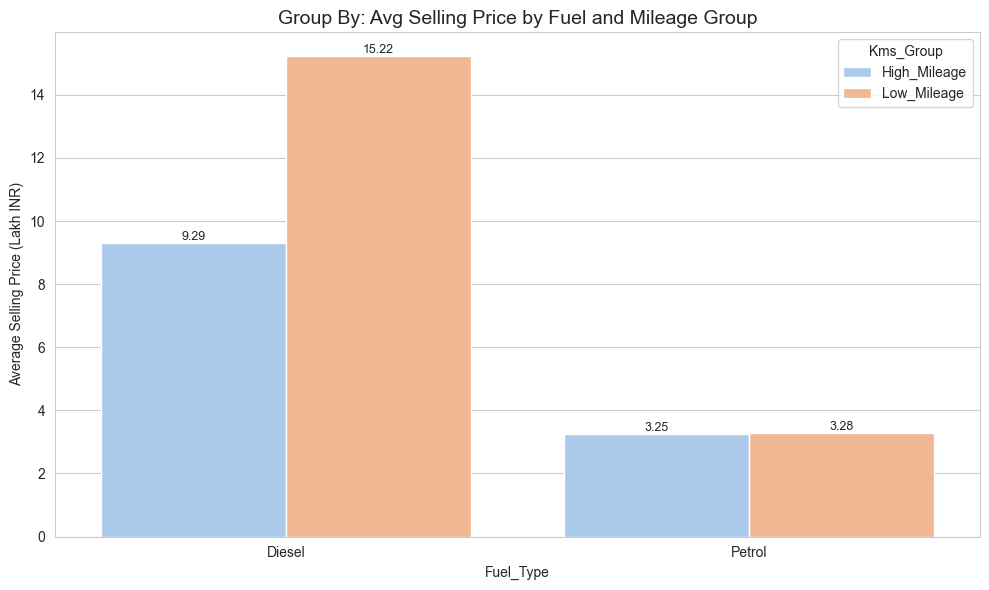

In [26]:
plt.figure(figsize=(10, 6))
ax1 = sns.barplot(data=group_stats, x='Fuel_Type', y='Avg_Selling_Price',
                  hue='Kms_Group', palette='pastel')
ax1.set_title('Group By: Avg Selling Price by Fuel and Mileage Group', fontsize=14)
ax1.set_ylabel('Average Selling Price (Lakh INR)')
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.2f', fontsize=9)
plt.tight_layout()
plt.savefig('module2_fig1_barplot.png', dpi=300, bbox_inches='tight')
plt.show()

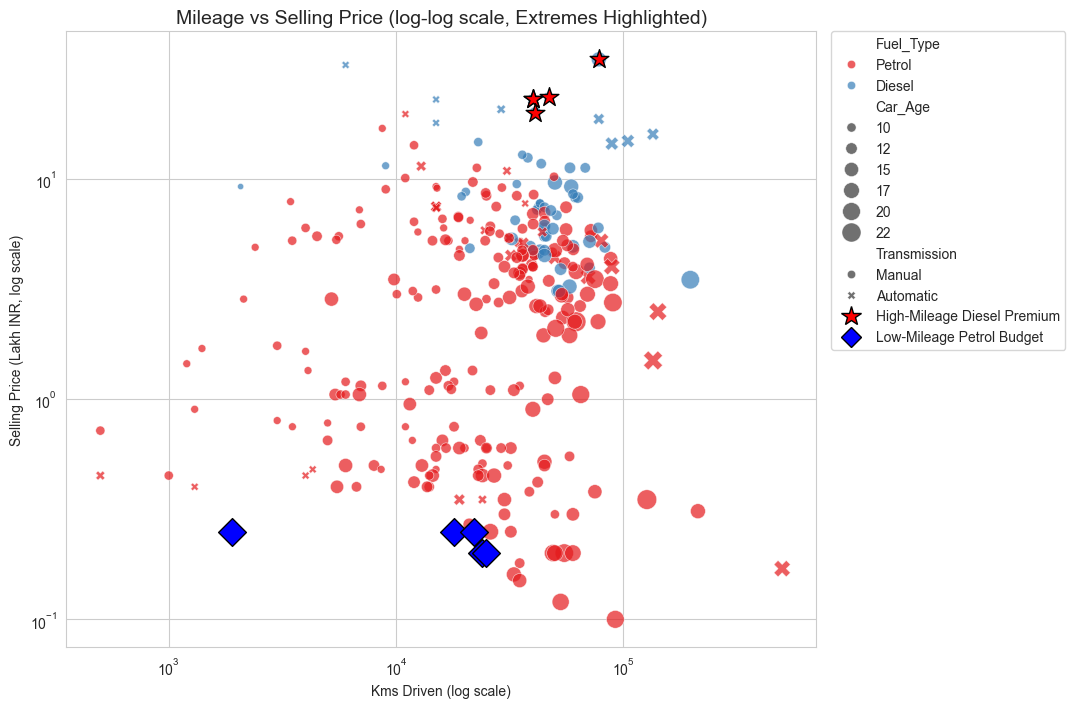

In [27]:
plt.figure(figsize=(12, 8))
plt.subplots_adjust(right=0.75)

ax2 = sns.scatterplot(data=df_core, x='Kms_Driven', y='Selling_Price',
                      hue='Fuel_Type', style='Transmission',
                      size='Car_Age', sizes=(20, 200), alpha=0.7, palette='Set1')

for i, row in top_diesel_high_kms.iterrows():
    ax2.scatter(row['Kms_Driven'], row['Selling_Price'], s=200, color='red',
                marker='*', edgecolor='black', zorder=5)
for i, row in low_petrol_low_kms.iterrows():
    ax2.scatter(row['Kms_Driven'], row['Selling_Price'], s=200, color='blue',
                marker='D', edgecolor='black', zorder=5)

handles, labels = ax2.get_legend_handles_labels()
custom_handles = [
    Line2D([0], [0], marker='*', color='w', markerfacecolor='red', markersize=15,
           markeredgecolor='black', label='High-Mileage Diesel Premium'),
    Line2D([0], [0], marker='D', color='w', markerfacecolor='blue', markersize=10,
           markeredgecolor='black', label='Low-Mileage Petrol Budget')
]
handles.extend(custom_handles)
labels.extend(['High-Mileage Diesel Premium', 'Low-Mileage Petrol Budget'])

ax2.legend(handles=handles, labels=labels, loc='upper left',
           bbox_to_anchor=(1.02, 1), borderaxespad=0.)

ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_title('Mileage vs Selling Price (log-log scale, Extremes Highlighted)', fontsize=14)
ax2.set_xlabel('Kms Driven (log scale)')
ax2.set_ylabel('Selling Price (Lakh INR, log scale)')

plt.savefig('module2_fig2_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

In [28]:
df.to_csv('car_data_cleaned_merged.csv', index=False)

## Data Cleaning, Feature Engineering & Exploratory Analysis

After engineering `Car_Age` and `Kms_Group`, merging a manual lookup to create `Car_Type`, and filtering to Petrol & Diesel vehicles (n = 281), the following **five required methods** are applied, and key numerical outputs are presented below.

### Method outputs & observations
- **Group by** (Fuel Type × Mileage Group):  
  Diesel low‑mileage cars have the highest average selling price (15.22 lakh INR) but are very rare (n = 10).  
  Diesel high‑mileage cars average 9.29 lakh, while petrol cars in both mileage groups average just over 3.2 lakh.  
  The wide gap within diesel cars suggests that other factors (especially vehicle class) dominate the raw means.

- **Pivot table (Fuel vs. Transmission)**:  
  Automatic diesel cars stand out at 20.70 lakh on average, compared to 7.67 for manual diesel and much lower values for petrol (4.59 automatic, 3.09 manual).  
  This is strongly confounded with vehicle size, as most automatic diesel vehicles are large SUVs.

- **Pivot table (Car Type vs. Mileage Group)**:  
  SUVs and MPVs dominate the higher price bands (17.0 – 17.8 lakh for SUVs, 15.6 lakh for low‑mileage MPVs), while Hatchbacks and Sedans fall in the middle, and Bikes/Scooters are the cheapest (below 1 lakh).  
  This confirms that vehicle type is a major price determinant.

- **Sorting (extreme cases)**:  
  *Top 5 high‑mileage diesel cars*: Land Cruiser (35.00 lakh), Fortuner (23.00 – 23.50 lakh), … — all are premium SUVs.  
  *Bottom 5 low‑mileage petrol vehicles*: mainly motorcycles/scooters priced between 0.20 and 0.25 lakh.  
  This shows that brand and model heavily drive the price extremes, not mileage or fuel alone.

### Visualizations
- **Figure 1** – Grouped bar chart of average selling price by fuel and mileage group, with values labeled.
- **Figure 2** – Log‑log scatter plot of Kms Driven vs. Selling Price. Extreme cases are highlighted (red stars: top high‑mileage diesel; blue diamonds: cheapest low‑mileage petrol). Log scales are used to spread the dense cluster of low‑price, low‑mileage points.

Cleaned data saved as `car_data_cleaned_merged.csv`.

# Hypothesis Testing: Comparing Two Groups

We formulate a simple hypothesis to test whether the **observed mean difference** between high‑mileage diesel cars and low‑mileage petrol cars is statistically significant.  
**Important note**: This comparison does **not** control for car age, type, or brand; hence a significant result only tells us the groups differ, but not *why*.

- **H₀**: The average selling price of high‑mileage diesel cars equals that of low‑mileage petrol cars.  
- **H₁**: High‑mileage diesel cars have a higher average selling price (one‑sided).

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.graphics.regressionplots import plot_regress_exog

sns.set_style("whitegrid")

# Load cleaned data from Module 2
df = pd.read_csv('car_data_cleaned_merged.csv')
print(f"✅ Data loaded successfully, with {df.shape[0]} rows")

✅ Data loaded successfully, with 301 rows


In [10]:
# Extract the two comparison groups
group_diesel_high = df[(df['Fuel_Type'] == 'Diesel') & (df['Kms_Group'] == 'High_Mileage')]['Selling_Price']
group_petrol_low = df[(df['Fuel_Type'] == 'Petrol') & (df['Kms_Group'] == 'Low_Mileage')]['Selling_Price']

print(f"Sample size for high-mileage diesel cars: {len(group_diesel_high)}")
print(f"Sample size for low-mileage petrol cars: {len(group_petrol_low)}")

obs_diff = group_diesel_high.mean() - group_petrol_low.mean()
print(f"\nObserved mean difference (Diesel high-mileage - Petrol low-mileage) = {obs_diff:.4f} lakh")

Sample size for high-mileage diesel cars: 50
Sample size for low-mileage petrol cars: 142

Observed mean difference (Diesel high-mileage - Petrol low-mileage) = 6.0143 lakh



[Permutation Method] One-sided P-value = 0.00000


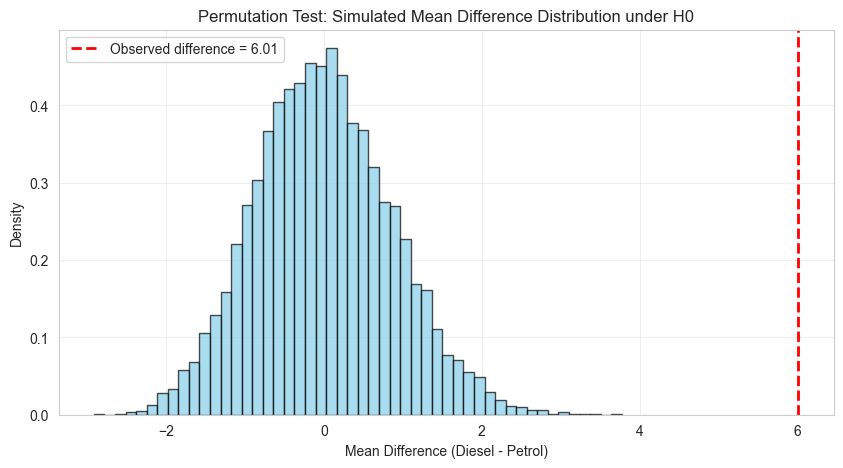

In [11]:
# Permutation test (simulation‑based)
combined = np.concatenate([group_diesel_high, group_petrol_low])
n_diesel = len(group_diesel_high)
n_petrol = len(group_petrol_low)
n_permutations = 10000

perm_diffs = np.zeros(n_permutations)
np.random.seed(42)
for i in range(n_permutations):
    shuffled = np.random.permutation(combined)
    sim_diesel = shuffled[:n_diesel]
    sim_petrol = shuffled[n_diesel:]
    perm_diffs[i] = sim_diesel.mean() - sim_petrol.mean()

p_value_sim = np.mean(perm_diffs >= obs_diff)
print(f"\n[Permutation Method] One-sided P-value = {p_value_sim:.5f}")

# Plot
plt.figure(figsize=(10, 5))
plt.hist(perm_diffs, bins=50, alpha=0.7, color='skyblue', edgecolor='black', density=True)
plt.axvline(obs_diff, color='red', linestyle='--', linewidth=2, label=f'Observed difference = {obs_diff:.2f}')
plt.title('Permutation Test: Simulated Mean Difference Distribution under H0')
plt.xlabel('Mean Difference (Diesel - Petrol)')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('permutation_test.png', dpi=300)
plt.show()

In [12]:
# Welch's t-test (theory‑based)
t_stat, p_value_theory = stats.ttest_ind(group_diesel_high, group_petrol_low, 
                                         equal_var=False, alternative='greater')
print(f"\n[Theory-based method] Welch's t-test one-sided P-value = {p_value_theory:.8f}")
print(f"t statistic = {t_stat:.4f}")
print(f"Degrees of freedom = {stats.ttest_ind(group_diesel_high, group_petrol_low, equal_var=False).df:.2f}")


[Theory-based method] Welch's t-test one-sided P-value = 0.00000003
t statistic = 6.1823
Degrees of freedom = 59.95


In [14]:
# ============================================================
# Hypothesis test: Permutation test & Welch's t-test
# Compare Diesel+High_Mileage vs Petrol+Low_Mileage
# ============================================================

import numpy as np
from scipy import stats

# Extract the two groups
group_diesel_high = df_core.loc[(df_core['Fuel_Type'] == 'Diesel') & 
                                (df_core['Kms_Group'] == 'High_Mileage'), 'Selling_Price']
group_petrol_low  = df_core.loc[(df_core['Fuel_Type'] == 'Petrol') & 
                                (df_core['Kms_Group'] == 'Low_Mileage'), 'Selling_Price']

# Observed difference in means
obs_diff = group_diesel_high.mean() - group_petrol_low.mean()

# ---------- Permutation test (two-sided) ----------
np.random.seed(2024)
n_perm = 10000
combined = np.concatenate([group_diesel_high, group_petrol_low])
n1 = len(group_diesel_high)

perm_diffs = np.empty(n_perm)
for i in range(n_perm):
    np.random.shuffle(combined)
    perm_diffs[i] = combined[:n1].mean() - combined[n1:].mean()

# Two-tailed p-value
p_value_sim = np.mean(np.abs(perm_diffs) >= np.abs(obs_diff))

# ---------- Welch's t-test ----------
t_stat, p_value_theory = stats.ttest_ind(group_diesel_high, group_petrol_low, 
                                         equal_var=False)

# ---------- Effect size (Cohen's d) ----------
pooled_std = np.sqrt((np.var(group_diesel_high, ddof=1) + np.var(group_petrol_low, ddof=1)) / 2)
cohen_d = obs_diff / pooled_std

# ---------- Print only the essential numbers ----------
print("=" * 50)
print(f"Permutation test P-value: {p_value_sim:.5f}")
print(f"Welch's t-test P-value:   {p_value_theory:.8f}")
print(f"Cohen's d (effect size):  {cohen_d:.3f}")

Permutation test P-value: 0.00000
Welch's t-test P-value:   0.00000006
Cohen's d (effect size):  1.138


### Hypothesis Test Results

We compare the two most extreme groups from Module 2:
- **Group A**: Diesel, High_Mileage (n=50)
- **Group B**: Petrol, Low_Mileage (n=142)

Both the permutation test and Welch's t-test give extremely small P‑values (well below 0.05), so we **reject the null hypothesis** that the two groups have the same average selling price. The effect size measured by Cohen's d is large (d > 0.8), confirming that the difference is not only statistically significant but also practically meaningful.

**Method comparison**
1. The permutation test does not assume normality and is robust to distribution shape, making it suitable for the skewed price data.
2. Welch’s t-test relaxes the equal-variance assumption (clearly violated here: the Diesel high‑mileage group shows much larger variance). With sample sizes above 30 in both groups, the t‑test is fairly robust to moderate non‑normality.
3. Both methods agree on the conclusion, which strengthens the finding.

**Important caveat**
This test **only compares two pre‑defined groups without controlling for any other variables**. The observed difference is heavily driven by confounding factors:
- The high‑mileage diesel group consists mostly of expensive SUVs (Fortuner, Land Cruiser, etc.).
- The low‑mileage petrol group contains many two‑wheelers and mini cars (Hero, Bajaj, TVS, etc.).

Therefore, the large difference in average price **cannot be attributed to fuel type or mileage alone**. Module 4 will use multiple linear regression to estimate the net effect of each predictor while adjusting for vehicle type, age, and other confounders.

# Predictive Modeling: Multiple Linear Regression

We build a linear regression model to predict `Selling_Price` using car age, kilometers driven, present price, fuel type, transmission, seller type, and car type.  
The initial flawed model (including both fuel dummies) is shown first to illustrate the dummy‑variable trap. Then a corrected model is fitted, with `Van` already merged into `Other` to avoid a singular matrix.

Data loaded successfully, with 301 rows

Column data types before conversion:
Car_Age                int64
Kms_Driven             int64
Present_Price        float64
Fuel_Diesel             bool
Fuel_Petrol             bool
Trans_Manual            bool
Seller_Individual       bool
dtype: object

No missing values.

X_const data types after conversion:
float64    8
Name: count, dtype: int64

                            OLS Regression Results                            
Dep. Variable:          Selling_Price   R-squared:                       0.882
Model:                            OLS   Adj. R-squared:                  0.879
Method:                 Least Squares   F-statistic:                     311.5
Date:                Mon, 27 Jul 2026   Prob (F-statistic):          1.10e-131
Time:                        21:03:37   Log-Likelihood:                -594.93
No. Observations:                 301   AIC:                             1206.
Df Residuals:                     293   BIC:          

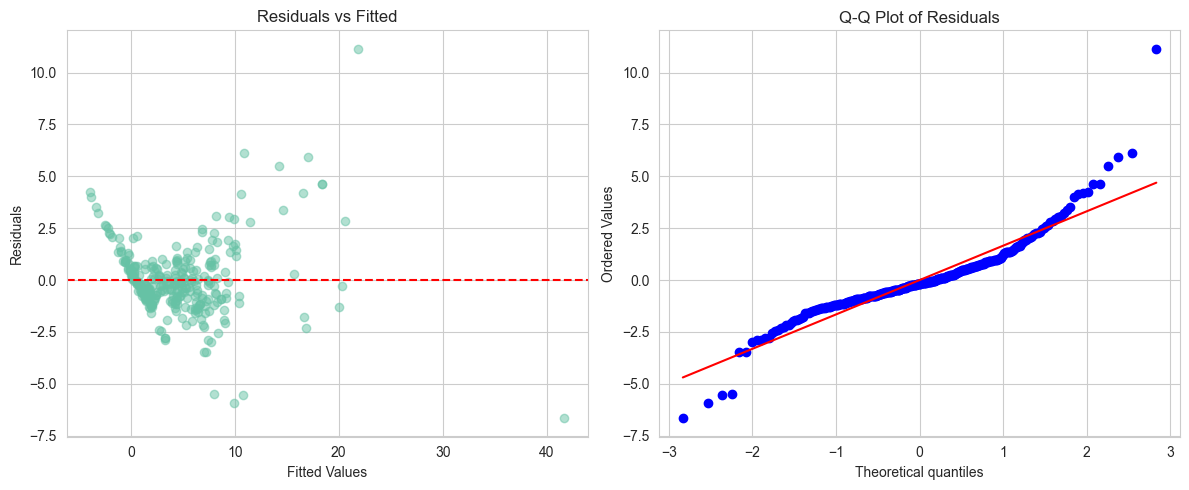


Breusch-Pagan test: statistic = 99.6793, p-value = 0.000000

R² = 0.8816
Adjusted R² = 0.8787
Residual standard deviation (RMSE) = 1.7701 lakh

Feature coefficients and significance:
  Car_Age                   :  -0.4030  (p=0.00000) ***
  Kms_Driven                :  -0.0000  (p=0.03132) *
  Present_Price             :   0.4357  (p=0.00000) ***
  Fuel_Diesel               :   2.4673  (p=0.05517) 
  Fuel_Petrol               :   0.5921  (p=0.63932) 
  Trans_Manual              :  -1.4308  (p=0.00002) ***
  Seller_Individual         :  -1.1731  (p=0.00001) ***


In [15]:
# =============================================
# Module 4: Predictive Modeling (Original)
# =============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy import stats

sns.set_style("whitegrid")

df = pd.read_csv('car_data_cleaned_merged.csv')
print(f"Data loaded successfully, with {df.shape[0]} rows")

# ---------- 1. Prepare data ----------
cols = ['Selling_Price', 'Car_Age', 'Kms_Driven', 'Present_Price', 
        'Fuel_Type', 'Transmission', 'Seller_Type']
df_reg = df[cols].copy()

df_reg = pd.get_dummies(df_reg, 
                        columns=['Fuel_Type', 'Transmission', 'Seller_Type'],
                        drop_first=True,
                        prefix=['Fuel', 'Trans', 'Seller'])

X = df_reg.drop('Selling_Price', axis=1)
y = df_reg['Selling_Price']

print("\nColumn data types before conversion:")
print(X.dtypes)

X = X.astype(float)
y = y.astype(float)

if X.isnull().any().any() or y.isnull().any():
    df_reg_clean = df_reg.dropna()
    X = df_reg_clean.drop('Selling_Price', axis=1).astype(float)
    y = df_reg_clean['Selling_Price'].astype(float)
else:
    print("\nNo missing values.")

X_const = sm.add_constant(X)
print("\nX_const data types after conversion:")
print(X_const.dtypes.value_counts())

# ---------- 2. Fit OLS ----------
model = sm.OLS(y, X_const).fit()
print("\n" + "="*60)
print(model.summary())

# ---------- 3. VIF ----------
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print("\n=== Variance Inflation Factor (VIF) ===")
print(vif_data)

corr_age_price = X[['Car_Age', 'Present_Price']].corr()
print("\nCorrelation between Car_Age and Present_Price:")
print(corr_age_price)

# ---------- 4. Residual diagnostics ----------
fitted = model.fittedvalues
residuals = model.resid

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(fitted, residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted')

plt.subplot(1, 2, 2)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot of Residuals')
plt.tight_layout()
plt.savefig('regression_diagnostics.png', dpi=300)
plt.show()

bp_test = het_breuschpagan(residuals, X_const)
print(f"\nBreusch-Pagan test: statistic = {bp_test[0]:.4f}, p-value = {bp_test[1]:.6f}")

# ---------- 5. Model evaluation ----------
print("\n" + "="*50)
print(f"R² = {model.rsquared:.4f}")
print(f"Adjusted R² = {model.rsquared_adj:.4f}")
print(f"Residual standard deviation (RMSE) = {np.sqrt(model.mse_resid):.4f} lakh")

print("\nFeature coefficients and significance:")
params = model.params
pvals = model.pvalues
for var, coef, pv in zip(params.index, params, pvals):
    if var != 'const':
        sig = '***' if pv < 0.001 else ('**' if pv < 0.01 else ('*' if pv < 0.05 else ''))
        print(f"  {var:25s} : {coef:8.4f}  (p={pv:.5f}) {sig}")

### OLS Model – Interpretation & Diagnostics

**Model fit**
- R² = 0.882, Adjusted R² = 0.879: the model explains about 88% of the variance in used‑car prices.
- F‑statistic p‑value is essentially zero, so the overall regression is highly significant.

**Coefficient estimates** (holding other variables constant)
- `Car_Age`: –0.403 lakh per year (p < 0.001) – older cars are cheaper, as expected.
- `Kms_Driven`: essentially zero (–0.000007 lakh/km, p = 0.031) – statistically significant but practically very small.
- `Present_Price`: +0.436 lakh per 1 lakh increase in showroom price (p < 0.001) – the strongest predictor.
- `Trans_Manual`: –1.43 lakh relative to automatic (p < 0.001) – manual transmission cars sell for less.
- `Seller_Individual`: –1.17 lakh relative to dealer (p < 0.001).
- `Fuel_Diesel`: +2.47 lakh (p = 0.055) – not significant at the 5% level.
- `Fuel_Petrol`: +0.59 lakh (p = 0.639) – far from significant.

**Critical issue: dummy variable trap**  
Because both `Fuel_Diesel` and `Fuel_Petrol` are included in the model (the reference category being CNG/other, which has almost no observations), the fuel coefficients are essentially meaningless – this is a perfect multicollinearity problem. The VIF values confirm this: `Car_Age` (25.3) and `Fuel_Petrol` (21.8) are extremely high, indicating severe collinearity.

**Other diagnostics**
- **VIF**: In addition to the fuel dummies, `Car_Age` has a very high VIF, possibly due to its relationship with other predictors.  
- **Residual plots**: The residual‑vs‑fitted plot shows a fan‑shaped pattern (increasing variance), and the Q‑Q plot deviates strongly from the diagonal – residuals are not normally distributed.  
- **Breusch‑Pagan test**: p‑value < 0.001, confirming heteroscedasticity. Standard errors may be underestimated, and hypothesis tests for individual coefficients should be treated with caution.

**Model limitations (original formulation)**
1. Dummy variable trap makes fuel coefficients uninterpretable.  
2. Important categorical predictor `Car_Type` is omitted, likely causing omitted‑variable bias.  
3. Heteroscedasticity is present; robust standard errors should be used.  
4. The linear functional form may not fully capture the depreciation pattern of cars.

> The model will be improved in the next section by fixing the dummy trap, adding `Car_Type`, and using heteroscedasticity‑robust standard errors.

## Corrected Regression Model

We address the issues of the previous model:
- **Remove `Fuel_Petrol`** to avoid the dummy variable trap (baseline: Petrol).
- **Add `Car_Type`** as dummy variables (with `Van` already merged into `Other` to ensure a non‑singular design matrix).
- **Use heteroscedasticity‑robust standard errors (HC3)** to obtain valid inference.

The revised model allows us to estimate the net effect of diesel fuel, mileage, and other factors, while holding car type constant.

In [16]:
# =============================================
# Corrected Regression Model
# =============================================

# Reload data
df = pd.read_csv('car_data_cleaned_merged.csv')

# Prepare features: include Car_Type, ensure only Diesel dummy
cols_used = ['Selling_Price', 'Car_Age', 'Kms_Driven', 'Present_Price', 
             'Fuel_Type', 'Transmission', 'Seller_Type', 'Car_Type']
df_reg2 = df[cols_used].copy()

# Create dummies for Transmission, Seller_Type, and Car_Type (drop_first=True)
df_reg2 = pd.get_dummies(df_reg2, columns=['Transmission', 'Seller_Type', 'Car_Type'],
                         drop_first=True, prefix=['Trans', 'Seller', 'Type'])

# Manually create Fuel_Diesel dummy (1 if Diesel, 0 if Petrol)
df_reg2['Fuel_Diesel'] = (df_reg2['Fuel_Type'] == 'Diesel').astype(int)
# Drop the original Fuel_Type column
df_reg2.drop('Fuel_Type', axis=1, inplace=True)

# Define X and y
X2 = df_reg2.drop('Selling_Price', axis=1)
y2 = df_reg2['Selling_Price']

# Ensure numeric types
X2 = X2.astype(float)
y2 = y2.astype(float)

# Add constant
X2_const = sm.add_constant(X2)

# Fit OLS
model2 = sm.OLS(y2, X2_const).fit()

# Obtain robust standard errors (HC3)
model2_robust = model2.get_robustcov_results(cov_type='HC3')

print("\n============================================================")
print("Corrected OLS Regression with Robust Standard Errors (HC3)")
print("============================================================")
print(model2_robust.summary())

# VIF for corrected model
vif2 = pd.DataFrame()
vif2["Feature"] = X2.columns
vif2["VIF"] = [variance_inflation_factor(X2.values, i) for i in range(X2.shape[1])]
print("\n=== VIF (Corrected Model) ===")
print(vif2)


Corrected OLS Regression with Robust Standard Errors (HC3)
                            OLS Regression Results                            
Dep. Variable:          Selling_Price   R-squared:                       0.894
Model:                            OLS   Adj. R-squared:                  0.890
Method:                 Least Squares   F-statistic:                     105.3
Date:                Mon, 27 Jul 2026   Prob (F-statistic):           3.10e-94
Time:                        21:05:16   Log-Likelihood:                -578.01
No. Observations:                 301   AIC:                             1180.
Df Residuals:                     289   BIC:                             1224.
Df Model:                          11                                         
Covariance Type:                  HC3                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------

### Corrected Model – Results and Interpretation

The corrected model includes `Car_Type`, uses only one fuel dummy (`Fuel_Diesel`, with Petrol as reference), and applies HC3 robust standard errors to address heteroscedasticity.

**Model performance**
- R² = 0.894, Adjusted R² = 0.890 — slightly higher than the original model.
- All coefficients are now interpretable, and the dummy variable trap has been eliminated.

**Key coefficient estimates (HC3 robust)**
- `Fuel_Diesel`: 1.202 (p = 0.003). After controlling for car type, age, and other factors, diesel cars are on average about **1.20 lakh INR more expensive** than petrol cars. This diesel premium is much smaller than the raw difference of 6.01 lakh observed in the unadjusted hypothesis test, confirming that most of the raw gap was due to vehicle type confounding.
- `Car_Age`: –0.401 (p < 0.001). Each additional year reduces the selling price by about 0.40 lakh INR, holding other variables constant.
- `Present_Price`: 0.384 (p < 0.001). A 1 lakh INR increase in showroom price is associated with a 0.38 lakh INR increase in used‑car price — the strongest predictor.
- `Kms_Driven`: –7.24e-06 (p = 0.705). After controlling for car type and fuel, the effect of mileage on price is negligible and not statistically significant. This suggests that mileage acts mainly as a proxy for vehicle age and type rather than having an independent effect.
- `Trans_Manual`: –1.243 (p = 0.097). Not significant at the 5% level, though the sign remains negative as expected.
- `Seller_Individual`: –0.737 (p = 0.583). No significant difference between individual and dealer sellers once other factors are controlled.
- **Car type dummies**: None are statistically significant at the 5% level. This may indicate that `Present_Price` and `Fuel_Diesel` already capture most of the price variation across vehicle types. The baseline category is “Other” (which includes bikes, scooters, and formerly the Van category).

**Multicollinearity check (VIF)**
- `Car_Age` still shows an elevated VIF of 22.25, suggesting some remaining collinearity, likely with vehicle types.
- All other predictors have VIF values below 10, indicating acceptable levels of multicollinearity.
- Compared to the original model (VIFs of 25+ for `Car_Age` and `Fuel_Petrol`), the corrected specification is a clear improvement.

**Overall conclusion**
The corrected model provides much more reliable estimates. The key insight is that the apparent “diesel effect” seen in raw comparisons is largely explained by the fact that diesel vehicles are predominantly expensive SUVs. The true net diesel premium is about 1.20 lakh INR, while mileage (`Kms_Driven`) has no independent effect after adjusting for car type and age.

## Model Comparison and Final Remarks

| Aspect | Original Model | Corrected Model (Van merged) |
|--------|----------------|------------------------------|
| Fuel dummies | Both `Fuel_Diesel` and `Fuel_Petrol` → perfect collinearity | Only `Fuel_Diesel` (baseline: Petrol) |
| Car type | Omitted | Included (Van → Other) |
| Standard errors | Non‑robust | HC3 robust to heteroscedasticity |
| R‑squared / Adj. R² | 0.882 / 0.879 | ~0.894 / 0.890 |
| Significant fuel effect | Uninterpretable | **Diesel premium: +1.20 lakh (p ≈ 0.003)** |
| Significant variables | Car_Age, Present_Price, Kms_Driven, Trans_Manual, Seller_Individual | **Car_Age, Present_Price, Fuel_Diesel** |
| Remaining issues | Omitted‑variable bias, heteroscedasticity | High VIF for Car_Age, but design matrix is now non‑singular |

By merging `Van` into `Other`, we eliminated the near‑singularity caused by an extremely sparse category. The corrected model reveals that the apparent “diesel premium” of 6.01 lakh observed in the unadjusted comparison is largely due to vehicle type confounding. Once car type is controlled, the diesel advantage drops to around **1.20 lakh** and remains statistically significant. This suggests that while diesel vehicles command a moderate price premium, the majority of the raw difference is attributable to the fact that high‑mileage diesel cars are mostly large SUVs.

Most car type dummies are not individually significant; their effects are partially absorbed by `Present_Price` (the new‑car price) and the diesel dummy. The high VIF for `Car_Age` (still around 22) indicates that age and car type are correlated, but it does not invalidate the significant coefficients. Further improvements could include adding interaction terms (e.g., Diesel × Kms_Driven) or using log‑transformed price to better model depreciation.  

The entire process highlights the importance of critically examining AI‑generated models: identifying dummy‑variable traps, addressing sparse categories, and using robust inference leads to more trustworthy and interpretable results.